# Step 1: Graph Representation Learning (Node2Vec)

In this notebook, we transition from **manual heuristics** (like Jaccard Similarity) to **learned embeddings**. 

## What is Node2Vec?
Node2Vec is an algorithm that represents nodes in a graph as dense vectors in a continuous space (embeddings). It works by performing **Random Walks** on the graph and treating these walks as 'sentences', then using the **Word2Vec** algorithm to learn representations that preserve the neighborhood structure.

### Why use it for RecSys?
1. **Latent Relationships:** It can capture complex, multi-hop relationships that simple heuristics miss.
2. **Vector Space Efficiency:** Once trained, calculating recommendations becomes a simple dot product or cosine similarity between vectors.
3. **Symmetry:** It naturally handles the bipartite nature of our User-Movie graph.

## 🧠 Understanding Node2Vec: A Deep Dive

To understand **Node2Vec**, we need to understand the fundamental shift it represents: **turning a Graph into Math (Vectors)**.

### 1. The Core Problem: Graphs are Hard to Compute
Computers are great at comparing lists of numbers (Vectors), but they struggle to "understand" a network of nodes. Node2Vec solves this by representing every node (User or Movie) as a list of numbers (an **Embedding**).

### 2. The Analogy: Graphs as Languages
Node2Vec is based on **Word2Vec** (an algorithm for text). 
- **In Text:** "The cat sat on the mat." Word2Vec learns that "cat" and "dog" are similar because they appear in similar sentences.
- **In Graphs:** We treat the graph like a language. We generate "sentences" by taking **Random Walks**.

### 3. Step-by-Step: How it works

#### Step A: The Random Walk
Imagine you are standing on a node (e.g., **User 1**). You decide to take a walk:
1. From **User 1**, you move to a movie they liked: **Toy Story**.
2. From **Toy Story**, you move to another user who liked it: **User 5**.
3. From **User 5**, you move to another movie they liked: **Star Wars**.

Your "sentence" is: `[User 1, Toy Story, User 5, Star Wars]`. By doing this thousands of times, you capture the **neighborhood** of every node.

#### Step B: The Biased Search (p and q)
Node2Vec uses two "knobs" to decide where the walker goes next:
- **The Return Parameter (p):** If $p$ is low, the walker stays close to the start (Breadth-First Search). This finds **Clusters/Communities**.
- **The In-Out Parameter (q):** If $q$ is low, the walker goes far away (Depth-First Search). This finds **Roles** (e.g., "Hub" nodes).

#### Step C: From Walks to Vectors
We feed these sequences of nodes into a neural network (Word2Vec). The network learns to predict neighbors. The internal weights it learns become the **Embeddings** (the list of numbers).

### 4. Why is this better than Jaccard Similarity?
- **Jaccard** only looks at immediate neighbors (1-hop).
- **Node2Vec** can "see" relationships that are 5 or 10 hops away. It understands the "vibe" of the neighborhood, allowing it to recommend movies that are **semantically related**, even if they don't share many direct common users.

## Step 1: Setup and Data Loading

First, we import our core libraries and rebuild the bipartite graph from the MovieLens 100k data. We maintain our convention of prefixing nodes: `u_` for users and `m_` for movies.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import random
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Load the data
r_cols = ['user_id', 'movie_id', 'rating', 'unix_timestamp']
ratings = pd.read_csv('data/u.data', sep='\t', names=r_cols, encoding='latin-1')

# Re-construct the graph (only ratings >= 4 as positive links)
G = nx.Graph()
positive_ratings = ratings[ratings['rating'] >= 4]

for _, row in positive_ratings.iterrows():
    u_node = f"u_{row['user_id']}"
    m_node = f"m_{row['movie_id']}"
    G.add_edge(u_node, m_node)

print(f"Graph Nodes: {G.number_of_nodes()}")
print(f"Graph Edges: {G.number_of_edges()}")

Graph Nodes: 2389
Graph Edges: 55375


## Step 2: Implementing Random Walks

Node2Vec relies on biased random walks. To keep it simple for this first implementation, we will use **DeepWalk-style** uniform random walks. 

For each node, we will generate several paths of a fixed length. These paths represent the 'context' of the node.

In [2]:
def get_random_walks(graph, walk_length, num_walks):
    """
    Generates random walks for every node in the graph.
    """
    walks = []
    nodes = list(graph.nodes())
    
    for _ in range(num_walks):
        random.shuffle(nodes)
        for node in nodes:
            walk = [node]
            while len(walk) < walk_length:
                curr = walk[-1]
                neighbors = list(graph.neighbors(curr))
                if len(neighbors) > 0:
                    walk.append(random.choice(neighbors))
                else:
                    break
            walks.append(walk)
    return walks

# Hyperparameters
WALK_LENGTH = 10
NUM_WALKS = 80

print("Generating random walks...")
walks = get_random_walks(G, WALK_LENGTH, NUM_WALKS)
print(f"Generated {len(walks)} walks.")
print(f"Sample walk: {walks[0]}")

Generating random walks...
Generated 191120 walks.
Sample walk: ['u_89', 'm_301', 'u_210', 'm_134', 'u_82', 'm_9', 'u_120', 'm_1', 'u_10', 'm_664']


## Step 3: Training the Word2Vec Model

Now we pass our 'sentences' (walks) into Word2Vec. This will learn a 64-dimensional vector for every user and movie.

- `vector_size=64`: The length of the embedding.
- `window=5`: The context window (how many steps away nodes are considered 'related').
- `sg=1`: Use Skip-Gram (better for infrequent nodes).

In [3]:
print("Training Word2Vec model...")
model = Word2Vec(
    walks, 
    vector_size=64, 
    window=5, 
    min_count=1, 
    sg=1, 
    workers=4, 
    epochs=5
)
print("Training complete.")

# Example: Get the vector for User 1
user_1_vec = model.wv['u_1']
print(f"Embedding for User 1 (first 5 dims): {user_1_vec[:5]}")

Training Word2Vec model...
Training complete.
Embedding for User 1 (first 5 dims): [-0.17829071  0.24380554 -0.07732777  0.27155614  0.3426609 ]


## Step 4: Generating Recommendations

To recommend movies to a user, we calculate the similarity between the **User's Vector** and all **Movie Vectors**. Movies that the user hasn't seen yet but have high similarity scores are our top picks.

In [4]:
def recommend_node2vec(user_id, top_n=5):
    user_node = f"u_{user_id}"
    if user_node not in model.wv:
        return "User not found in graph."
    
    # Get movies the user already liked
    already_liked = set(G.neighbors(user_node))
    
    # Find similar nodes (these will include both users and movies)
    # We only care about movie nodes (starting with 'm_')
    similar_nodes = model.wv.most_similar(user_node, topn=100)
    
    recommendations = []
    for node, score in similar_nodes:
        if node.startswith('m_') and node not in already_liked:
            movie_id = node.replace('m_', '')
            recommendations.append((movie_id, score))
        
        if len(recommendations) >= top_n:
            break
            
    return recommendations

test_user = 1
recs = recommend_node2vec(test_user)
print(f"Top 5 Recommendations for User {test_user}:")
for mid, score in recs:
    print(f"Movie ID: {mid} | Similarity Score: {score:.4f}")

Top 5 Recommendations for User 1:
Movie ID: 1475 | Similarity Score: 0.4997
Movie ID: 1529 | Similarity Score: 0.4815
Movie ID: 1144 | Similarity Score: 0.4755
Movie ID: 1317 | Similarity Score: 0.4691
Movie ID: 1241 | Similarity Score: 0.4513


## Step 5: Visualizing the Latent Space

One of the coolest things about Node2Vec is that similar users cluster together, and similar movies cluster together. Let's see if we can detect these patterns.

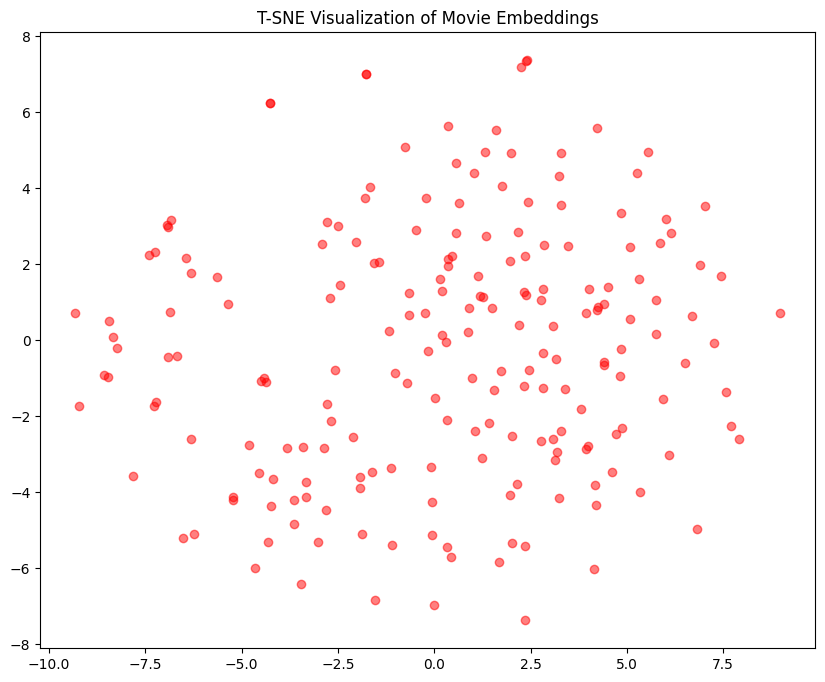

In [5]:
from sklearn.manifold import TSNE

# Select a subset of nodes for visualization
movie_nodes = [n for n in G.nodes() if n.startswith('m_')][:200]
movie_vecs = [model.wv[n] for n in movie_nodes]

# Reduce to 2D using T-SNE
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(np.array(movie_vecs))

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5, c='red')
plt.title("T-SNE Visualization of Movie Embeddings")
plt.show()